# Urban Flood Risk Prediction

**Authored by:** Hoang Hiep Pham

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite skills:** Python, Data Manipulation, Data Visualisation

# Introduction
Urban flooding is an increasing challenge in many cities due to urbanisation, dense infrastructure, and changing rainfall patterns. In Melbourne, highly built-up areas with large impervious surfaces and limited drainage capacity may become more vulnerable to flooding during heavy rainfall events. Flood risk can affect transportation, public safety, infrastructure, and economic activities. Therefore, identifying vulnerable regions is important for supporting urban planning, infrastructure management, and future flood mitigation strategies.
<br><br>

### User story
**As** a Melbourne urban planner and infrastructure analyst,<br>
**I want** to identify areas with higher urban flood vulnerability based on drainage infrastructure, elevation, vegetation coverage, and impervious surfaces,<br>
**so that** I can support flood mitigation planning, improve infrastructure resilience, and identify regions that may require drainage upgrades or further investigation during heavy rainfall periods.
<br><br>

### What This Use Case Will Teach You
This project demonstrates how spatial data and unsupervised machine learning techniques can be used to analyse urban flood vulnerability without labelled flood-event data. The use case provides practical experience in:

Spatial data preprocessing and grid-based feature engineering
Integrating multiple geospatial datasets into a unified analytical framework
Applying clustering models such as K-Means and Gaussian Mixture Models (GMM) for spatial risk analysis
Performing seasonal and rainfall accumulation analysis using temporal rainfall data
Visualising spatial vulnerability patterns using probabilistic and cluster-based mapping approaches
Understanding how urban infrastructure and environmental factors influence flood vulnerability
<br><br>

### Datasets Used
* Dataset 1: https://data.melbourne.vic.gov.au/explore/dataset/stormwater-pits/information/
* Dataset 2: https://data.melbourne.vic.gov.au/explore/dataset/drainpipes/information/
* Dataset 3: https://data.melbourne.vic.gov.au/explore/dataset/2023-building-footprints/information/
* Dataset 4: https://data.melbourne.vic.gov.au/explore/dataset/road-segments-with-surface-type/information/
* Dataset 5: https://data.melbourne.vic.gov.au/explore/dataset/tree-canopies-2021-urban-forest/information/
* Dataset 6: https://www.bom.gov.au/jsp/ncc/cdio/weatherData/av?p_nccObsCode=136&p_display_type=dailyDataFile&p_startYear=&p_c=&p_stn_num=086338
<br>

### Workflow:
1. General setting & Data preparation
2. Data preprocessing
3. Spatial features creating
4. Modelling & Prediction
5. Results Visualisation & Interpretation
6. Recommendations & Conslusion

## Section 1: General setting & Data preparation

We start with importing the required libraries. Optional installation commands are included for any packages not previously installed on your machine.

In [ ]:
# import libraries
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from io import StringIO
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
from math import nan
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# optional if needed
# ! pip install geopandas
# ! pip install contextily
# ! pip install requests

### Collecting data
* 5 spatial datasets with specific features are downloaded from the City of Melbourne Open Data (CoM).<br>
* 1 Daily Rainfall dataset is downloaded from the Australian Government Bureau of Meteorology (BoM), measuring daily rainfall over the years at Olympic Park station.<br>

A custom function downloads five datasets directly from the City of Melbourne's (CoM) public API portal. The Bureau of Meteorology (BoM) dataset is pre-downloaded and retrieved from Google Cloud Storage during execution.

In [ ]:
# Datasets from CoM
# define function to colect data
def collect_data(dataset_id, limit=-1, format="csv"):
  base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
  url = f'{base_url}{dataset_id}/exports/{format}'
  params = {'limit': limit, 'lang': 'en','timezone': 'UTC'}
  try:
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = StringIO(response.text)
    if format == 'geojson':
      df = gpd.read_file(data)
    else:
      df = pd.read_csv(data, delimiter=';')
    print(f'Successfully loaded {dataset_id}, {df.shape[0]} rows and {df.shape[1]} columns, {format} format.')
    return df
  except requests.exceptions.RequestException as e:
    print(f'Error loading {dataset_id}: {e}.')
    return None

# collect datasets
pits_raw = collect_data('stormwater-pits', format='geojson')
pipes_raw = collect_data('drainpipes', format='geojson')
buildings_raw = collect_data('2023-building-footprints', format='geojson')
roads_raw = collect_data('road-segments-with-surface-type', format='geojson')
trees_raw = collect_data('tree-canopies-2021-urban-forest', format='geojson')

# Rainfall data from BoM
# dataset 6 is stored at https://drive.google.com/file/d/1lRTEPZHGKj2PKISCgEsFsVxqzLkyw-5F/view?usp=sharing
rainfall_id = '1lRTEPZHGKj2PKISCgEsFsVxqzLkyw-5F'
try:
  rainfall_raw  = pd.read_csv(f'https://drive.google.com/uc?id={rainfall_id}')
  print(f'Successfully loaded rainfall data, {rainfall_raw.shape[0]} rows and {rainfall_raw.shape[1]} columns.')
except Exception as e:
  print(f'Error loading rainfall data: {e}.')

Successfully loaded stormwater-pits, 21113 rows and 13 columns, geojson format.
Successfully loaded drainpipes, 17242 rows and 17 columns, geojson format.
Successfully loaded 2023-building-footprints, 41701 rows and 13 columns, geojson format.
Successfully loaded road-segments-with-surface-type, 56519 rows and 10 columns, geojson format.
Successfully loaded tree-canopies-2021-urban-forest, 57980 rows and 2 columns, geojson format.
Successfully loaded rainfall data, 4843 rows and 8 columns.


## Section 2: Data preprocessing
### 2.1 Spatial data preprocessing
#### 2.1.1 Exploring raw datasets

The raw datasets are inspected with displaying the first few rows and missing values of each raw spatial dataset. This is used to understand the structure of the data, identify useful columns, and check data quality before cleaning and feature creation.

In [ ]:
# Stormwater pits dataset
print(f'Pits data:\n{'='*20}\n{pits_raw.head(3)}\n\n')
print(f'Pits null values:\n{'='*20}\n{pits_raw.isnull().sum()}')

Pits data:
   asset_number            asset_description construction_material_lupvalue  \
0       1596911     SWD Pit - Grated Manhole                          Brick   
1       1759114          SWD Pit - Lane Type               In Situ Concrete   
2       1146782  SWD Pit - Grated Side Entry                          Brick   

   grate_length grate_material_lupvalue  grate_width  \
0           NaN               Cast Iron          NaN   
1         450.0              Mild Steel        450.0   
2         900.0              Mild Steel        430.0   

                                model_descr_lupvalue model_no_lupvalue  \
0                           SWD Pit - Grated Manhole        300413-001   
1              SWD Pit - Laneway Type - Unclassified        300407-000   
2  SWD Pit - Grated Side Entry Pit - Non Standard...        300402-003   

  object_type_lupvalue overflow_kerb_lupvalue        lat         lon  \
0       Grated Manhole                   None -37.792906  144.956536   
1     

In [ ]:
# Drainpipes dataset
print(f'Pipes data:\n{'='*20}\n{pipes_raw.head(3)}\n\n')
print(f'Pipes null values:\n{'='*20}\n{pipes_raw.isnull().sum()}')

Pipes data:
                                        geo_point_2d built  dnstr_pit  \
0  {'lon': 144.9723773392074, 'lat': -37.83235998...   NaT  1472763.0   
1  {'lon': 144.9741777544205, 'lat': -37.83075901...   NaT  1472766.0   
2  {'lon': 144.97380384007778, 'lat': -37.8310363...   NaT  1472768.0   

  upstr_inv  upstr_pit        ref  width_mm  condition    carrying  \
0      None  1472761.0  1473265.0       NaN        3.0  Stormwater   
1      None  1472784.0  1473274.0       NaN        3.0  Stormwater   
2      None  1472810.0  1473277.0       NaN        3.0  Stormwater   

            operator  diameter material  height_mm  form mat_desc dnstr_inv  \
0  City of Melbourne     150.0  Unknown        NaN  Pipe     None      None   
1  City of Melbourne     150.0  Plastic        NaN  Pipe     None      None   
2  City of Melbourne     150.0  Plastic        NaN  Pipe     None      None   

                                            geometry  
0  LINESTRING (144.97236 -37.83236, 144.97

In [ ]:
# 2023 Building Footprints dataset
print(f'Buildings data:\n{'='*20}\n{buildings_raw.head(3)}\n\n')
print(f'Buildings null values:\n{'='*20}\n{buildings_raw.isnull().sum()}')

Buildings data:
                                        geo_point_2d objectid structure_id  \
0  {'lon': 144.95673941735046, 'lat': -37.8000353...    20012       815949   
1  {'lon': 144.9077552355766, 'lat': -37.84308942...    20027       804149   
2  {'lon': 144.97921111, 'lat': -37.832043207400005}    20048       815174   

  footprint_type roof_type  footprint_max_elevation  footprint_min_elevation  \
0      Structure      Flat                     97.5                     91.5   
1      Structure      Flat                      7.5                      3.0   
2      Structure      Flat                     18.5                     16.5   

   structure_max_elevation  structure_min_elevation  footprint_extrusion  \
0                    101.0                     27.5                  6.0   
1                      7.5                      3.0                  4.5   
2                     18.5                     16.5                  2.0   

   structure_extrusion date_captured  \
0    

In [ ]:
# Road segments, with surface type dataset
print(f'Roads data:\n{'='*20}\n{roads_raw.head(3)}\n\n')
print(f'Roads null values:\n{'='*20}\n{roads_raw.isnull().sum()}')

Roads data:
                                        geo_point_2d  assetno condition  \
0  {'lon': 144.94368406627316, 'lat': -37.8194477...  1434230     3.937   
1  {'lon': 144.9750594901909, 'lat': -37.79600916...  1419861      None   
2  {'lon': 144.9476316634999, 'lat': -37.80911547...  1445696         4   

            material  length instaldate         type  area_sqm width  \
0           Concrete     NaN 2012-09-13      Footway   243.436  None   
1  Bluestone Pitcher     NaN 1990-01-01  Carriageway     3.691  None   
2    Granitic Gravel     NaN        NaT       Median    10.493  None   

                                            geometry  
0  MULTIPOLYGON (((144.94382 -37.81969, 144.94379...  
1  MULTIPOLYGON (((144.97508 -37.79601, 144.97508...  
2  MULTIPOLYGON (((144.94763 -37.8091, 144.94765 ...  


Roads null values:
geo_point_2d        0
assetno             0
condition        2842
material           18
length          27251
instaldate       3281
type                0
are

In [ ]:
# Tree Canopies 2021 dataset
print(f'Trees data:\n{'='*20}\n{trees_raw.head(3)}\n\n')
print(f'Trees null values:\n{'='*20}\n{trees_raw.isnull().sum()}')

Trees data:
                                        geo_point_2d  \
0  {'lon': 144.9578491713787, 'lat': -37.79540177...   
1  {'lon': 144.9514339834316, 'lat': -37.79535552...   
2  {'lon': 144.97057737168868, 'lat': -37.7956921...   

                                            geometry  
0  MULTIPOLYGON (((144.95785 -37.79534, 144.95786...  
1  MULTIPOLYGON (((144.95143 -37.79535, 144.95144...  
2  MULTIPOLYGON (((144.97056 -37.79569, 144.97058...  


Trees null values:
geo_point_2d    0
geometry        0
dtype: int64


#### 2.1.2 Visualising raw datasets

A good way to understand geographical and spatial data is by plotting them on a map. The purpose is to visually inspect the geographic distribution of stormwater pits, drainpipes, buildings, roads, and trees across the study area before further processing.

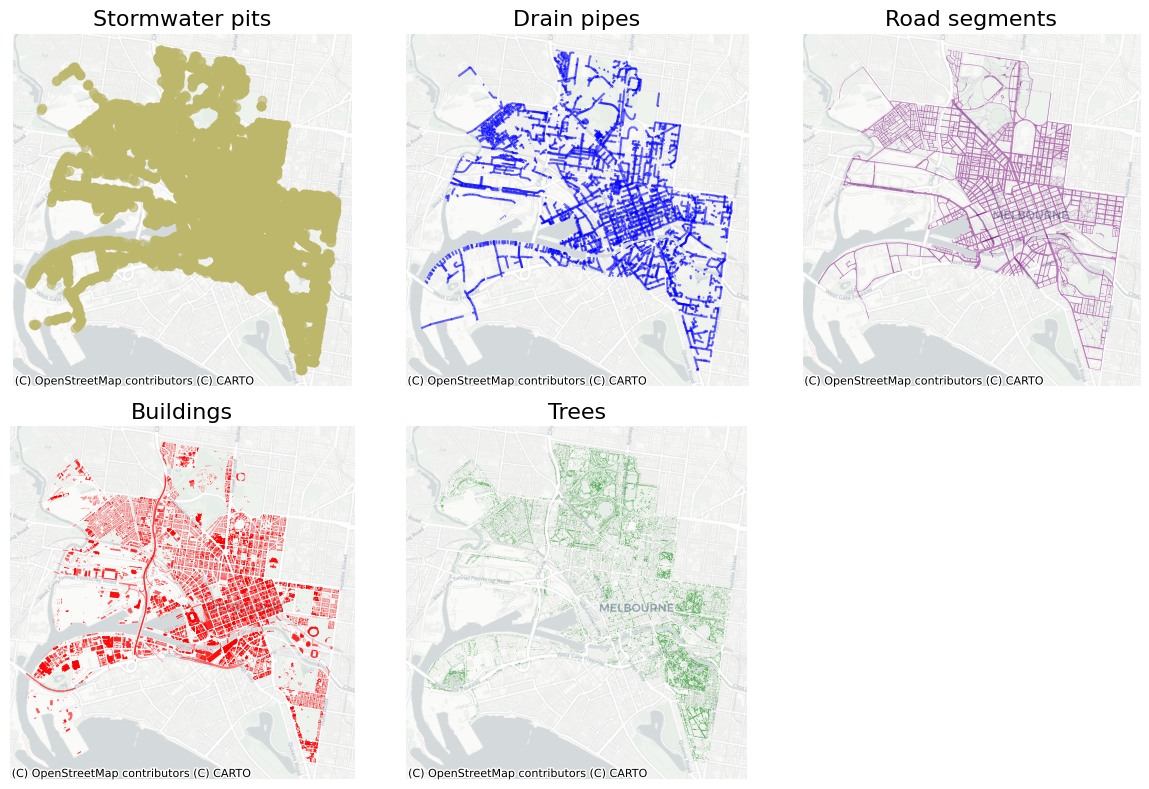

In [ ]:
# visualize data
datasets = {
    'Stormwater pits': {'df': pits_raw, 'color': 'darkkhaki'},
    'Drain pipes': {'df': pipes_raw, 'color': 'blue'},
    'Road segments': {'df': roads_raw, 'color': 'purple'},
    'Buildings': {'df': buildings_raw, 'color': 'red'},
    'Trees': {'df': trees_raw, 'color': 'green'}
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (name, info) in enumerate(datasets.items()):
  ax = axes[i]
  df = info['df'].to_crs(epsg=3857)
  color = info['color']
  df.plot(ax=ax, color=color, alpha=0.6)
  ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)
  ax.axis('off')
  ax.set_title(name, fontsize=16)
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

#### 2.1.3 Spatial data handling

This step prepares the raw spatial datasets for feature extraction. The original files contain many columns that are not needed for the flood risk model, so I keep only the useful attributes and geometry columns. I also remove missing or duplicated records to reduce data errors. For the road dataset, I convert road surface types into a pervious score, because different surfaces allow different levels of water absorption.

In [ ]:
# select nescessary columns
pits = pits_raw['geometry'].drop_duplicates()
pipes = pipes_raw.dropna(subset=['diameter'])[['geometry', 'diameter']].drop_duplicates()
buildings = buildings_raw[['geometry', 'footprint_min_elevation']].drop_duplicates()
roads = roads_raw.dropna(subset=['material'])[['geometry', 'material']].drop_duplicates()
trees = trees_raw['geometry'].drop_duplicates()

# check materials
print(f'Roads material values: \n{roads['material'].unique()}')
# eliminate "other" and "not known" values
roads = roads[(roads['material'].str.lower() != "other") & (roads['material'].str.lower() != "not known")]

# score pervious values
def score_pervious(material):
    m = material.strip().lower()
    # impervious
    if any(keyword in m for keyword in [
        'concrete', 'hma', 'asphalt', 'bluestone', 'granite', 'brick',
        'steel', 'plastic', 'terrazzo', 'precast', 'pre cast',
        'cast in situ', 'cast-in-situ', 'masonry', 'iron'
    ]):
        return 0.1
    # semi-pervious
    elif any(keyword in m for keyword in [
        'crushed rock', 'gravel', 'granitec', 'granitic', 'pebble',
        'paver', 'mixture', 'timber', 'wood', 'crazy paving'
    ]):
        return 0.5
    # pervious
    elif any(keyword in m for keyword in [
        'grass', 'turf', 'plants', 'mulch', 'sand', 'unmade'
    ]):
        return 0.9
    return None

roads['pervious_score'] = roads['material'].apply(score_pervious)
print(f'\nRoads dataset with pervious score:\n{roads}')

Roads material values: 
['Concrete' 'Bluestone Pitcher' 'Granitic Gravel'
 'Bluestone Paver (1000x500x40)' 'Dressed Bluestone'
 'Pre Cast Exposed Agg' 'Cast in Situ Off Form' 'HMA' 'HMA Footpath (CBD)'
 '3 Row Bluestone Pitcher' 'HMA Footpath (Non CBD)'
 '1 Row Bluestone Pitcher' '5 Row Bluestone Pitcher'
 '4 Row Bluestone Pitcher' 'Cast in Situ Exposed Agg'
 '2 Row Bluestone Pitcher' 'Concrete Paver' 'Pre Cast Off Form'
 'Granite Paver' 'Steel' 'Crushed Rock' 'Terrazzo Paver' 'Turf'
 '6 Row Bluestone Pitcher' '15 Row Bluestone Pitcher' 'Timber'
 'HMA-Porous' 'Bluestone Paver (Other)' 'Pebble Paving' 'Other Paver'
 'Other' 'Brick' 'Brick Paver' 'Sawn Bluestone Block (100x100x100)'
 'Plants' 'Masonry' 'Mulch' 'Crazy Paving' 'Unmade' 'Synthetic Turf'
 'Precast Concrete' 'Cast-In-Situ Concrete' 'Bluestone Triangle Paver'
 '9 Row Bluestone Pitcher' 'Woodpaving' '8 Row Bluestone Pitcher'
 '7 Row Bluestone Pitcher' 'Mixture of Materials' 'Wrought Iron'
 'Not Known' 'Plastic/Composite' 'Sand'

### 2.2 Temporal data preprocessing
#### 2.2.1 Exploring & Cleaning Rainfall dataset

I clean the rainfall dataset so it can be used together with the spatial data. I keep only the useful columns, rename them into clearer names, and filter the records to the study period from 2016 to 2025. I also check for missing, duplicated, or invalid rainfall values. This is important because the prediction needs consistent rainfall information before it can be linked with the flood risk analysis.

In [ ]:
# display head of datasets and check null values
print(f'Rainfall first 3 rows:\n{'='*20}\n{rainfall_raw.head(3)}\n')
print(f'Rainfall year range: {rainfall_raw['Year'].unique()}\n\n')

rainfall = rainfall_raw.copy()

# select nescessary columns
rainfall = rainfall[['Year', 'Month', 'Day', 'Rainfall amount (millimetres)']]
rainfall.columns = ['year', 'month', 'day', 'rainfall_amount']

# select 10 recent years from 2016 to 2025 and sort by time
rainfall = rainfall[(rainfall['year'] >= 2016) & (rainfall['year'] <= 2025)]
rainfall = rainfall.sort_values(['year', 'month', 'day']).reset_index(drop=True)

# check data validation
print(f'Select Rainfall data from 2016 to 2025\n{'='*20}')
print(f'Total Rainfall observations: {len(rainfall)}')
print(f'Number of rows with null values: {rainfall['rainfall_amount'].isnull().sum()}')
print(f'Number of rows with values less than 0: {rainfall[rainfall["rainfall_amount"] < 0].shape[0]}')
print(f'Duplicated values: {rainfall_raw.duplicated().sum()}\n\n')

# assess null values
print(f'Null values:\n{'='*20}\n{rainfall[rainfall.isnull().any(axis=1)]}')
# fill some missng values with 0
rainfall = rainfall.fillna(0)

# recheck data
print('\n\nPreprocessed Rainfall data')
print('='*26)
print(f'Number of rows with null values: {rainfall['rainfall_amount'].isnull().sum()}')
print(f'\nRainfall first and last 5 rows:\n{rainfall}')

Rainfall first 3 rows:
  Product code  Bureau of Meteorology station number  Year  Month  Day  \
0   IDCJAC0009                                 86338  2013      1    1   
1   IDCJAC0009                                 86338  2013      1    2   
2   IDCJAC0009                                 86338  2013      1    3   

   Rainfall amount (millimetres)  \
0                            NaN   
1                            NaN   
2                            NaN   

   Period over which rainfall was measured (days) Quality  
0                                             NaN     NaN  
1                                             NaN     NaN  
2                                             NaN     NaN  

Rainfall year range: [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026]


Select Rainfall data from 2016 to 2025
Total Rainfall observations: 3653
Number of rows with null values: 4
Number of rows with values less than 0: 0
Duplicated values: 0


Null values:
      year  m

#### 2.2.2 Visualising Rainfall data

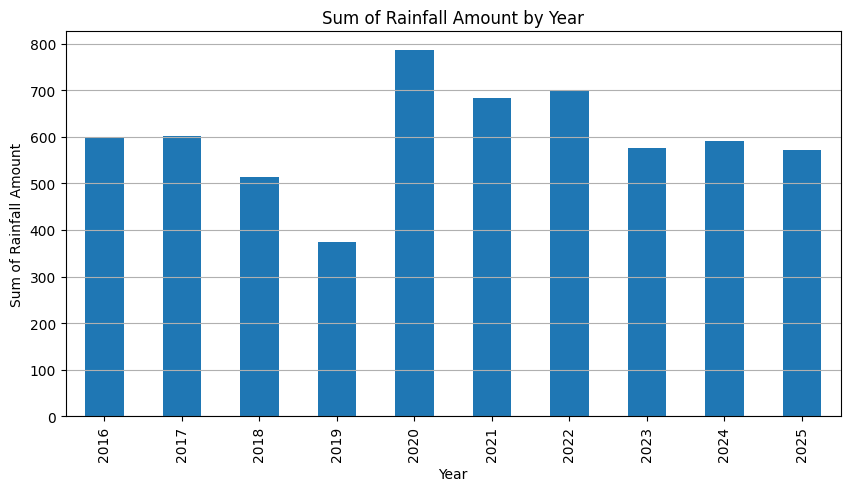

In [ ]:
plt.figure(figsize=(10,5))
rainfall.groupby('year')['rainfall_amount'].sum().plot(kind='bar')
plt.title('Sum of Rainfall Amount by Year')
plt.xlabel('Year')
plt.ylabel('Sum of Rainfall Amount')
plt.grid(axis='y')
plt.show()

## Section 3: Features creating
### 3.1 Creating geometry grid data frame & extracting spatial features
To prepare for model training, selected spatial features are converted into a score-based dataframe.<br>
I divide the study area into regular 1 km grid cells. This is necessary because the raw spatial datasets have different geometry types, such as points, lines, and polygons. By using grid cells, all datasets can be summarised into the same spatial unit. Each grid cell will become one row in the final machine learning dataset.

**Features creating justification:**
* pit_count: Higher numbers of drainage pits indicate greater stormwater collection capacity and potentially lower surface water accumulation.
* tree_count: Trees help reduce runoff by intercepting rainfall and increasing water infiltration into the soil.
* pipe_drainage_score: A higher drainage pipe score represents stronger stormwater transport capacity and more efficient water removal.
* avg_min_elevation: Lower elevation areas are more susceptible to water accumulation and flooding due to natural runoff flow.
* road_pervious_score: More pervious road surfaces allow greater infiltration and reduce surface runoff generation.

In [ ]:
# create grids data frame for spartial variables
# xmin, ymin, xmax, ymax = buildings.to_crs("EPSG:28355").total_bounds
xmin, ymin, xmax, ymax = roads.to_crs("EPSG:28355").total_bounds
cell_size = 1000

grid_cells = []
for x in np.arange(xmin, xmax, cell_size):
  for y in np.arange(ymin, ymax, cell_size):
    grid_cells.append(box(x, y, x + cell_size, y + cell_size))
grids = gpd.GeoDataFrame(geometry = grid_cells, crs = "EPSG:28355")
grids["id"] = range(len(grids))
grids = grids[['id', 'geometry']]

## create features and merge into grids
# pits feature: total number of pits per area
pits = gpd.GeoDataFrame(pits, geometry='geometry')
pits = pits.to_crs(grids.crs)
pits_joined = gpd.sjoin(pits, grids, how="inner", predicate="intersects")
pits_features = (
    pits_joined.groupby("id").size()
    .reset_index(name="pit_count")
)
grids = grids.merge(pits_features, on='id', how='left')

# trees feature: total number of trees per area
trees = gpd.GeoDataFrame(trees, geometry='geometry')
trees = trees.to_crs(grids.crs)
trees_joined = gpd.sjoin(trees, grids, how="inner", predicate="intersects")
trees_features = (
    trees_joined.groupby("id").size()
    .reset_index(name="tree_count")
)
grids = grids.merge(trees_features, on='id', how='left')

# pipes feature: combination of total number of pipes and average diameter
pipes = pipes.to_crs(grids.crs)
pipes_joined = gpd.sjoin(pipes, grids, how="inner", predicate="intersects")
pipes_features = (
    pipes_joined.groupby("id").agg(
        pipe_count=("geometry", "count"),
        avg_pipe_diameter=("diameter", "mean")
    ).reset_index()
)
pipes_features['pipe_drainage_score'] = pipes_features['pipe_count'] * pipes_features['avg_pipe_diameter']
pipes_features.drop(columns=['pipe_count', 'avg_pipe_diameter'], inplace=True)
grids = grids.merge(pipes_features, on='id', how='left')

# buildings feature: combination of total number of buildings and average min elevator
buildings = buildings.to_crs(grids.crs)
buildings_joined = gpd.sjoin(buildings, grids, how="inner", predicate="intersects")
buildings_features = (
    buildings_joined.groupby("id").agg(
        avg_min_elevation=("footprint_min_elevation", "mean")
    ).reset_index()
)
grids = grids.merge(buildings_features, on='id', how='left')

# roads feature: combination of total number of roads and pervious capacity
roads = roads.to_crs(grids.crs)
roads_joined = gpd.sjoin(roads, grids, how="inner", predicate="intersects")
roads_features = (
    roads_joined.groupby("id").agg(
        road_count=("geometry", "count"),
        avg_pervious_score=("pervious_score", "mean")
    ).reset_index()
)
roads_features['road_pervious_score'] = roads_features['road_count'] * roads_features['avg_pervious_score']
roads_features.drop(columns=['road_count', 'avg_pervious_score'], inplace=True)
grids = grids.merge(roads_features, on='id', how='left')

# drop grid with nan values
grids = grids[~grids['road_pervious_score'].isna()].reset_index(drop=True)
grids = grids[grids['pipe_drainage_score']!=0].reset_index(drop=True)

print('Spatial data:')
print('='*50)
print(grids.head(5))
print(f'\n\nNull values:\n{grids.isnull().sum()}')

Spatial data:
   id                                           geometry  pit_count  \
0   2  POLYGON ((316210.674 5810839.569, 316210.674 5...      141.0   
1   3  POLYGON ((316210.674 5811839.569, 316210.674 5...        3.0   
2   4  POLYGON ((316210.674 5812839.569, 316210.674 5...      106.0   
3   5  POLYGON ((316210.674 5813839.569, 316210.674 5...       50.0   
4   6  POLYGON ((316210.674 5814839.569, 316210.674 5...        2.0   

   tree_count  pipe_drainage_score  avg_min_elevation  road_pervious_score  
0      1139.0              73500.0           5.771429                 35.8  
1        74.0               2700.0           3.153043                  0.8  
2       120.0              22050.0           3.623913                 26.6  
3       163.0              10275.0           3.291429                 17.0  
4       525.0                300.0          10.717476                  3.5  


Null values:
id                     0
geometry               0
pit_count              0
tree_co

Each spatial dataset are joined to the grid cells. I use spatial joins to count or summarise features inside each grid, such as the number of stormwater pits, drainage pipe length, tree canopy coverage, building elevation, and road surface condition. This changes raw map layers into numerical features that can be used by the machine learning models.

### 3.2 Visualising cleaned spartial datasets on grid areas
The cleaned and processed datasets are visualised within the grid structure to better understand spatial patterns.

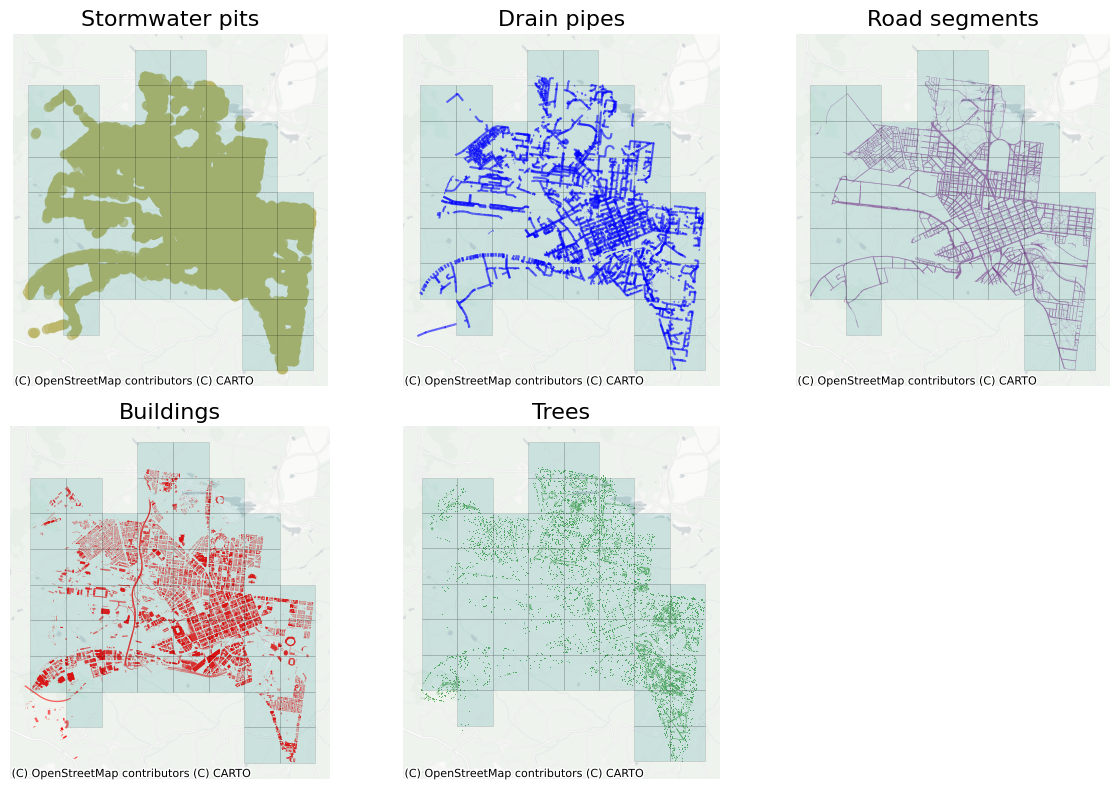

In [ ]:
datasets = {
    'Stormwater pits': {'df': pits, 'color': 'darkkhaki'},
    'Drain pipes': {'df': pipes, 'color': 'blue'},
    'Road segments': {'df': roads, 'color': 'purple'},
    'Buildings': {'df': buildings, 'color': 'red'},
    'Trees': {'df': trees, 'color': 'green'}
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (name, info) in enumerate(datasets.items()):
  ax = axes[i]
  df = info['df']
  color = info['color']
  df.plot(ax=ax, color=color, alpha=0.6)
  grids.plot(ax=ax, color='teal', alpha=0.15, edgecolor='black', linewidth=0.5)
  ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)
  ax.axis('off')
  ax.set_title(name, fontsize=16)
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

## Section 4: Modelling & Prediction

**Model selection:**

K-Means clustering & Gaussian Mixture Models are chosen for this use case.

This step applies unsupervised learning to group areas with similar flood-related characteristics. Since there is no labelled flood risk dataset, clustering is used to identify patterns in the grid features. K-Means creates clear risk groups, while GMM provides a probability-based view of high-risk areas. These results are then mapped to support flood risk interpretation.

Both clustering approaches are used to classify grid cells into different flood risk categories. Comparing both methods improves the robustness of the flood vulnerability analysis.

In [ ]:
grids_labeled = grids.copy()

# Feature standardisation
X = grids_labeled.drop(columns=['id', 'geometry'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means model
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
# Add label to data
grids_labeled['km_cluster'] = km_labels

# Gaussian Mixture model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)
# Add label to data
grids_labeled['gmm_cluster'] = gmm_labels

# print prediction
print(grids_labeled.head(3))

   id                                           geometry  pit_count  \
0   2  POLYGON ((316210.674 5810839.569, 316210.674 5...      141.0   
1   3  POLYGON ((316210.674 5811839.569, 316210.674 5...        3.0   
2   4  POLYGON ((316210.674 5812839.569, 316210.674 5...      106.0   

   tree_count  pipe_drainage_score  avg_min_elevation  road_pervious_score  \
0      1139.0              73500.0           5.771429                 35.8   
1        74.0               2700.0           3.153043                  0.8   
2       120.0              22050.0           3.623913                 26.6   

   km_cluster  gmm_cluster  
0           0            0  
1           0            0  
2           0            0  


**Inspecting Cluster Prediction Results**

The clustering outputs are evaluated by examining feature averages and spatial distributions across predicted groups. This interpretation step helps determine which clusters represent low, moderate, or high flood risk.

In [ ]:
# Cluster summary for KM
km_summary = grids_labeled.drop(columns=['id', 'geometry']).groupby('km_cluster').mean()
print(f'\n\nCluster average values for K-Means model:\n{'='*20}\n{km_summary}\n\n')

# Cluster summary for GMM
gmm_summary = grids_labeled.drop(columns=['id', 'geometry']).groupby('gmm_cluster').mean()
print(f'\n\nCluster average values for Gaussian Mixture model:\n{'='*20}\n{gmm_summary}')



Cluster average values for K-Means model:
              pit_count   tree_count  pipe_drainage_score  avg_min_elevation  \
km_cluster                                                                     
0            116.826087   526.478261         47633.695652          11.785660   
1           1213.875000  1736.750000        322825.000000          35.399258   
2            456.052632  1663.526316        146096.052632          24.235481   

            road_pervious_score  gmm_cluster  
km_cluster                                    
0                     35.134783     0.173913  
1                    424.962500     2.000000  
2                    183.789474     1.157895  




Cluster average values for Gaussian Mixture model:
               pit_count   tree_count  pipe_drainage_score  avg_min_elevation  \
gmm_cluster                                                                     
0             117.047619   591.238095         50411.904762          10.328958   
1             336.2500

Based on the features creating justification and the cluster average values summary, a higher value indicates a lower risk of flood.

Flood risk prediction from K-Means model can be seperated in order:
* Cluster 1: Low risk
* Cluster 2: Moderate risk
* Cluster 0: High risk

Flood risk prediction from Gaussian Mixture model can be interpreted by Cluster 0 which represents the highest risk. The higher the probability, the more vulnerable the area is to flooding.

## Section 5: Results Visualisation & Interpretation
### 5.1 Results Visualisation

To evaluate the model predictions, I visualised the results from both clustering algorithms. The K-Means predictions are plotted using three distinct colors to represent fixed risk levels. In contrast, the GMM predictions are plotted as a continuous gradient based on high-risk probabilities, where darker shades signify higher risk.

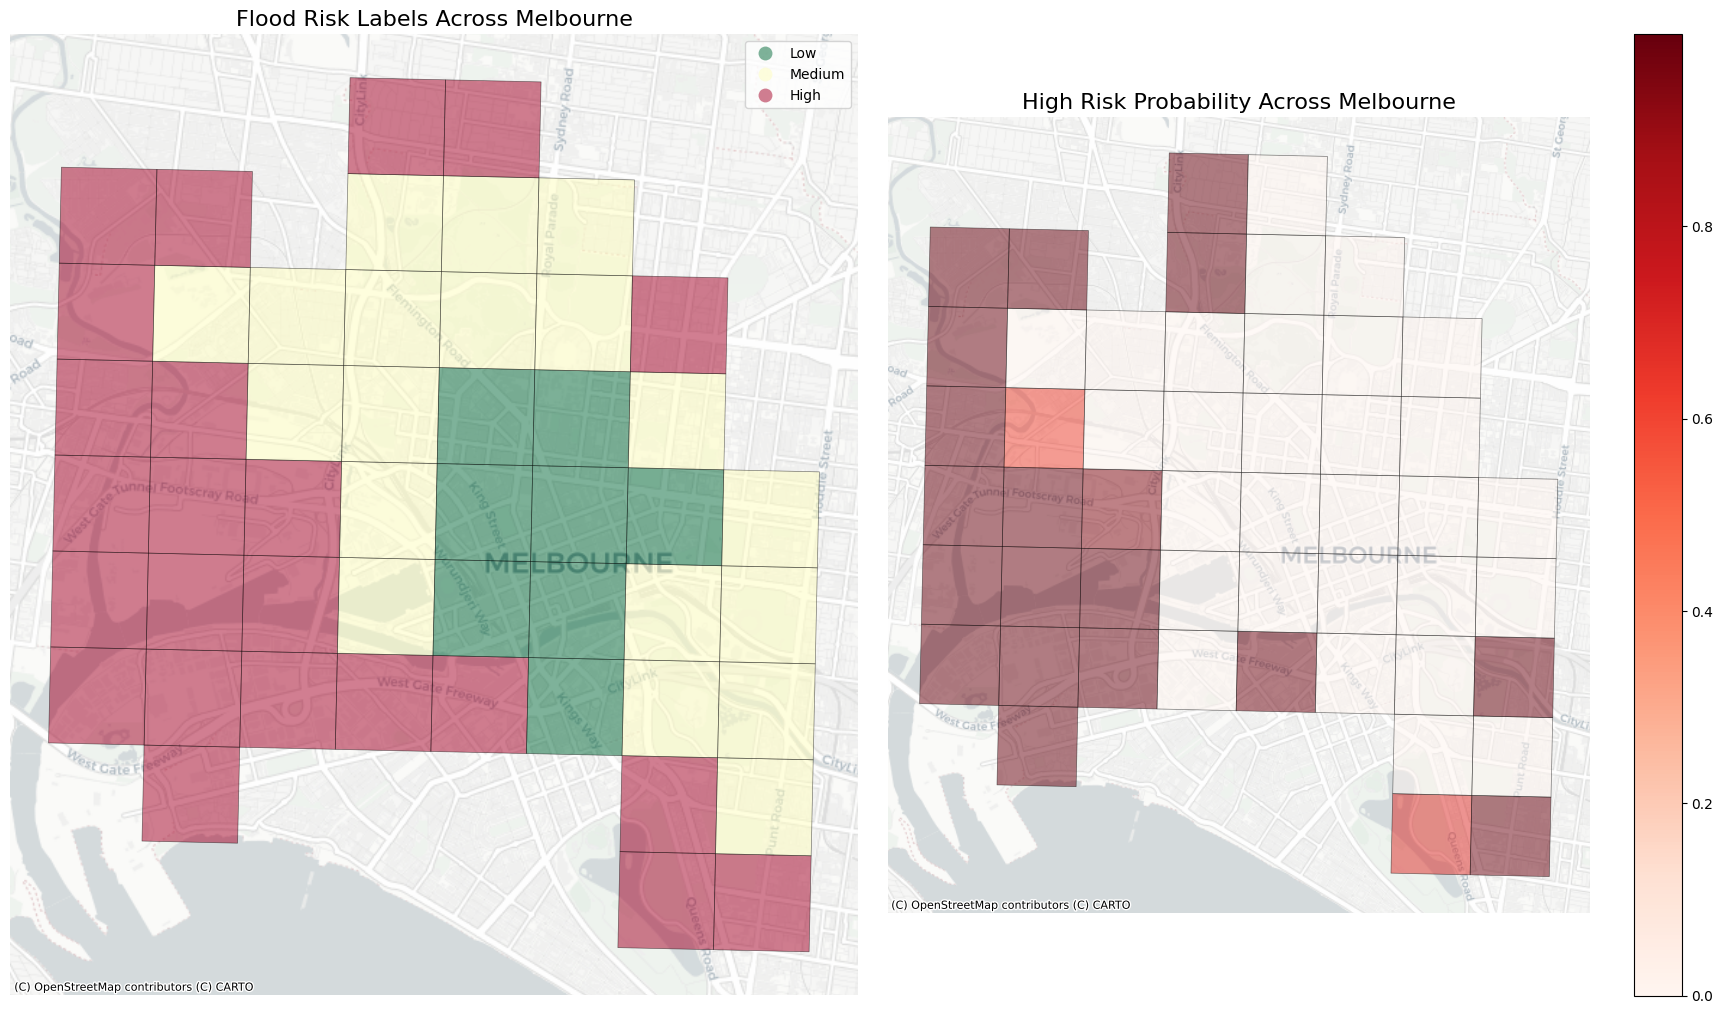

In [ ]:
# map risk level form KM
risk_label_map = {
    1: "Low",
    2: "Medium",
    0: "High"}
grids_labeled['risk_label'] = grids_labeled['km_cluster'].map(risk_label_map)
grids_labeled['risk_label'] = pd.Categorical(grids_labeled['risk_label'],
    categories=['Low', 'Medium', 'High'], ordered=True)
# high risk probability form GMM
grids_labeled['high_risk_prob'] = gmm_probs[:, 0]


# plot prediction result
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
grids_plot = grids_labeled.to_crs(epsg=3857)
# prediction from KM
grids_plot.plot(
    ax=axes[0],
    column='risk_label',
    cmap='RdYlGn_r',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5,
    legend=True
)
ctx.add_basemap(
    axes[0],
    source=ctx.providers.CartoDB.Positron
)
axes[0].axis('off')
axes[0].set_title('Flood Risk Labels Across Melbourne', fontsize=16)

# prediction from GMM
grids_plot.plot(
    ax=axes[1],
    column='high_risk_prob',
    cmap='Reds',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5,
    legend=True
)
ctx.add_basemap(
    axes[1],
    source=ctx.providers.CartoDB.Positron
)
axes[1].axis('off')
axes[1].set_title('High Risk Probability Across Melbourne', fontsize=16)

plt.tight_layout()
plt.show()

**Additional Temporal Rainfall Analysis**

This step integrates long-term rainfall trends with spatial clustering results to provide a comprehensive context for flood risk. By computing monthly averages from daily rainfall datasets, seasonal patterns are analysed over several years to understand how changing precipitation influence vulnerable regions.

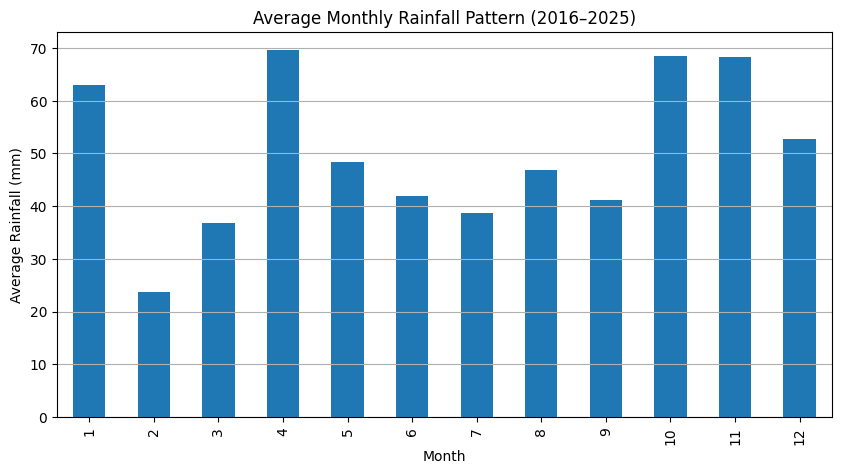

In [ ]:
rainfall_df = rainfall.copy()
# compute monthly average
monthly_rainfall = (rainfall_df.groupby(['year', 'month'])['rainfall_amount'].sum().reset_index())
monthly_avg = (monthly_rainfall.groupby('month')['rainfall_amount'].mean())

# plot monthly average rainfall
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Monthly Rainfall Pattern (2016–2025)')
plt.grid(axis='y')
plt.show()

### 5.2 Results Interpretation

**Spatial flood risk distribution**<br>
* High risk areas are mainly concentrated in the western and south-western parts of Melbourne, with several isolated high risk grids in the north and south-east.
* Low risk areas are mostly located in the central and eastern regions.

This spatial pattern suggests that flood vulnerability is not evenly distributed across Melbourne and is strongly influenced by local infrastructure and environmental characteristics.<br>
The cluster summary indicates that high-risk grids generally have:
* Lower numbers of stormwater pits
* Lower pipe drainage capacity
* Lower tree coverage
* Lower average elevation
* Less permeable road surfaces

The probability heatmap further confirms the clustering results when several western grid cells show very high flood probabilities (above 80%), indicating consistently vulnerable areas.

These characteristics reduce the ability of an area to absorb or discharge stormwater, increasing the likelihood of surface flooding.
<br><br>

**Rainfall pattern analysis**<br>
The rainfall analysis from 2016–2025 shows clear seasonal variation.
* Rainfall peaks in April, October, and November, with average monthly rainfall close to 70 mm.
* Lower rainfall occurs in February and March.

This indicates that flood risk may increase during wetter months, particularly when heavy rainfall occurs in already vulnerable urban areas.

## Section 6: Recommendations & Conslusion

**Recommendations**
* Prioritise flood mitigation in high risk areas: Melbourne planners should focus on western and south-western high risk areas by improving drainage systems, adding stormwater pits, and increasing maintenance to reduce flooding.
* Increase green infrastructure: Areas with low tree coverage should add more trees, rain gardens, green roofs, and permeable landscaping to improve water absorption and reduce runoff.
* Improve road surface permeability: High risk areas should use permeable pavements, WSUD, and better roadside drainage to reduce water build-up during heavy rain.
* Use seasonal rainfall for early warning: As rainfall is highest in April, October, and November, authorities should inspect drainage systems, monitor flooding, and prepare emergency responses before wet seasons.

**Use Case Limitations**
* This project has some limitations due to data availability. The rainfall analysis uses data from only one rainfall station (Olympic Park station). Although the City of Melbourne is a relatively small area, rainfall may still vary between locations during heavy storms. Therefore, the rainfall data may not fully represent local rainfall conditions across all grids.
* In addition, the project uses unsupervised learning methods because there is no labelled historical flood dataset available. As a result, the identified flood risk levels represent estimated vulnerability patterns rather than actual flood events.
* The analysis also focuses mainly on spatial and environmental features, such as drainage infrastructure, elevation, vegetation, and impervious surfaces. Other factors, including detailed water flow and underground drainage conditions, were not included.

**Conclusion**

This use case developed a grid based urban flood vulnerability prediction framework for the City of Melbourne using spatial infrastructure and environmental data. Machine learning models were used to identify areas with different levels of flood vulnerability. Seasonal rainfall trend analysis were also conducted using historical rainfall data to support the interpretation of flood vulnerability during wetter periods.

Overall, the project demonstrates how spatial data analysis and unsupervised machine learning can support urban flood vulnerability assessment even without labelled flood event data.